In [1]:
import pandas as pd
import numpy as np
import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from wordcloud import WordCloud

In [2]:
%pip install wordcloud


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
df = pd.read_csv("C://Users//Admin//Downloads//Tweets.csv")

df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [3]:
df.shape

(27481, 4)

In [4]:
df.columns

Index(['textID', 'text', 'selected_text', 'sentiment'], dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   textID         27481 non-null  str  
 1   text           27480 non-null  str  
 2   selected_text  27480 non-null  str  
 3   sentiment      27481 non-null  str  
dtypes: str(4)
memory usage: 4.1 MB


In [7]:
df.isnull().sum()

textID           0
text             1
selected_text    1
sentiment        0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df = df[['text', 'sentiment']]

In [10]:
df.head()

,text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative


In [11]:
df = df.dropna(subset=['text'])

In [12]:
df.isnull().sum()

text         0
sentiment    0
dtype: int64

In [13]:
df['sentiment'].value_counts()

sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64

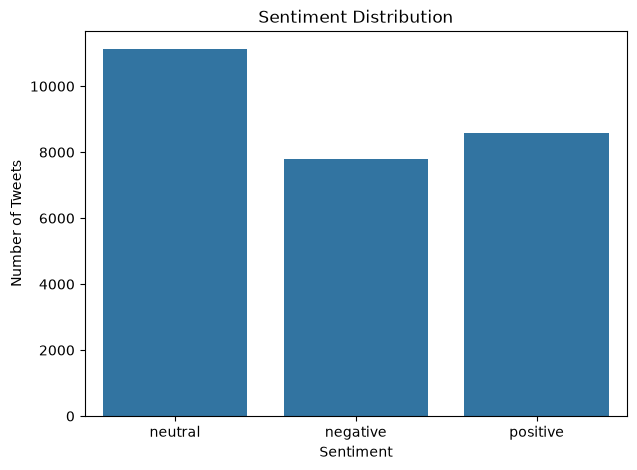

In [14]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='sentiment')

plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')

plt.show()

### Observation

The dataset contains three sentiment categories: positive, negative,
and neutral. Neutral tweets represent the largest class, followed by
positive and negative tweets. Although the classes are not perfectly
balanced, all three categories have a substantial number of examples
for model training.

In [15]:
#Text preprocessing
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stop_words = set(ENGLISH_STOP_WORDS)

In [16]:
def clean_text(text):
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)
    
    # Remove mentions
    text = re.sub(r'@\w+', ' ', text)
    
    # Remove hashtag symbol
    text = text.replace('#', ' ')
    
    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # Tokenization
    words = text.split()
    
    # Remove stopwords
    words = [word for word in words if word not in stop_words]
    
    return ' '.join(words)

In [17]:
df['clean_text'] = df['text'].apply(clean_text)

In [18]:
df[['text', 'clean_text']].head(10)

,text,clean_text
0,"I`d have responded, if I were going",d responded going
1,Sooo SAD I will miss you here in San Diego!!!,sooo sad miss san diego
2,my boss is bullying me...,boss bullying
3,what interview! leave me alone,interview leave
4,"Sons of ****, why couldn`t they put them on t...",sons couldn t releases bought
5,http://www.dothebouncy.com/smf - some shameles...,shameless plugging best rangers forum earth
6,2am feedings for the baby are fun when he is a...,feedings baby fun smiles coos
7,Soooo high,soooo high
8,Both of you,
9,Journey!? Wow... u just became cooler. hehe....,journey wow u just cooler hehe possible


In [19]:
df = df[df['clean_text'].str.strip() != '']

In [20]:
df.shape

(27371, 3)

## TF-IDF Feature Extraction

TF-IDF stands for Term Frequency-Inverse Document Frequency.

It converts text into numerical values that machine learning models
can understand.

TF-IDF gives higher importance to words that are useful for
distinguishing documents while reducing the importance of words that
occur very frequently across the dataset.

In [21]:
X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [22]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [23]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

In [24]:
print(classification_report(y_test, nb_pred))

              precision    recall  f1-score   support

    negative       0.74      0.48      0.58      1554
     neutral       0.56      0.78      0.65      2206
    positive       0.75      0.61      0.67      1715

    accuracy                           0.64      5475
   macro avg       0.68      0.62      0.64      5475
weighted avg       0.67      0.64      0.64      5475



In [25]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

In [26]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

    negative       0.72      0.58      0.65      1554
     neutral       0.62      0.75      0.68      2206
    positive       0.77      0.70      0.74      1715

    accuracy                           0.69      5475
   macro avg       0.71      0.68      0.69      5475
weighted avg       0.70      0.69      0.69      5475



In [27]:
results = pd.DataFrame({
    'Model': ['Naive Bayes', 'Logistic Regression'],
    
    'Accuracy': [
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, lr_pred)
    ],
    
    'Precision': [
        precision_score(y_test, nb_pred, average='weighted'),
        precision_score(y_test, lr_pred, average='weighted')
    ],
    
    'Recall': [
        recall_score(y_test, nb_pred, average='weighted'),
        recall_score(y_test, lr_pred, average='weighted')
    ],
    
    'F1 Score': [
        f1_score(y_test, nb_pred, average='weighted'),
        f1_score(y_test, lr_pred, average='weighted')
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.641644,0.671072,0.641644,0.638962
1,Logistic Regression,0.688219,0.697731,0.688219,0.688064


### Model Comparison

Logistic Regression performed better than Multinomial Naive Bayes
across accuracy, precision, recall, and F1-score.

Therefore, Logistic Regression was selected as the better-performing
model for this sentiment classification task.

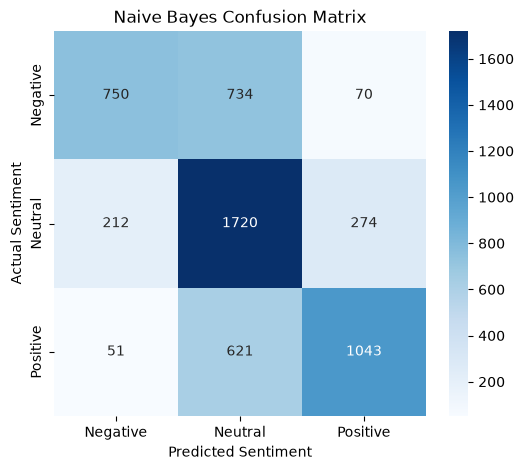

In [28]:
cm_nb = confusion_matrix(
    y_test,
    nb_pred,
    labels=['negative', 'neutral', 'positive']
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Neutral', 'Positive'],
    yticklabels=['Negative', 'Neutral', 'Positive']
)

plt.title('Naive Bayes Confusion Matrix')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')

plt.show()

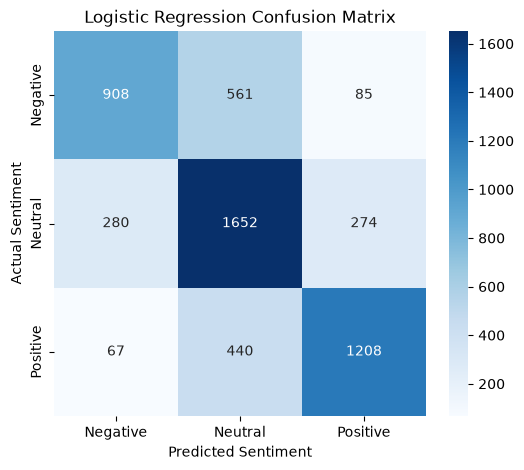

In [29]:
cm_lr = confusion_matrix(
    y_test,
    lr_pred,
    labels=['negative', 'neutral', 'positive']
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Neutral', 'Positive'],
    yticklabels=['Negative', 'Neutral', 'Positive']
)

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')

plt.show()

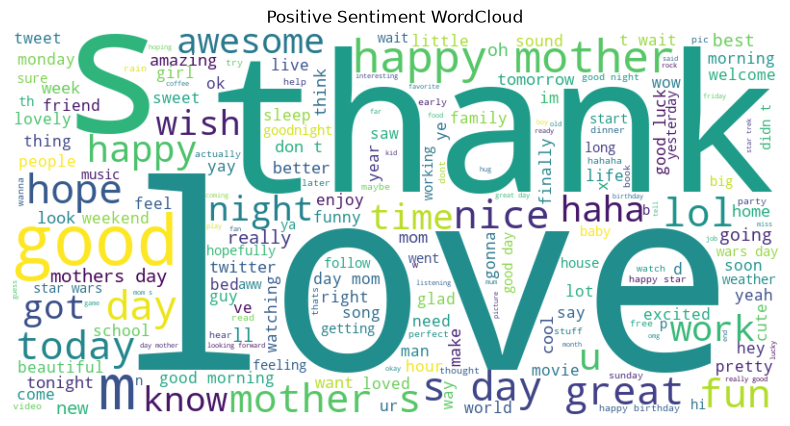

In [30]:
positive_text = ' '.join(
    df[df['sentiment'] == 'positive']['clean_text']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title('Positive Sentiment WordCloud')

plt.show()

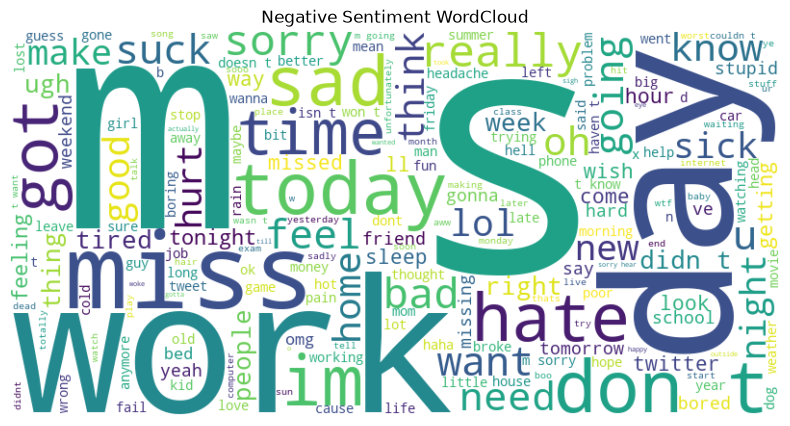

In [31]:
negative_text = ' '.join(
    df[df['sentiment'] == 'negative']['clean_text']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title('Negative Sentiment WordCloud')

plt.show()

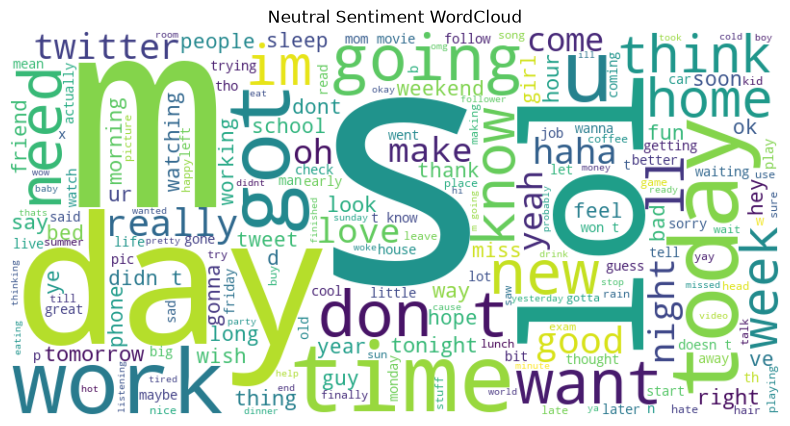

In [32]:
neutral_text = ' '.join(
    df[df['sentiment'] == 'neutral']['clean_text']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(neutral_text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title('Neutral Sentiment WordCloud')

plt.show()

In [33]:
error_df = pd.DataFrame({
    'text': X_test.values,
    'actual': y_test.values,
    'predicted': lr_pred
})

In [34]:
errors = error_df[
    error_df['actual'] != error_df['predicted']
]

In [35]:
errors.head(5)

,text,actual,predicted
2,writing report cards soooo tired amazing day c...,positive,neutral
6,holy need bad gotta wait tomorrow,neutral,negative
17,work miserable day,negative,neutral
19,didn t know misunderstood ur eyes u did love m...,neutral,positive
20,day fkn ugly matches mood unfortunatly time bl...,negative,neutral


## Error Analysis

Five incorrectly classified tweets were examined to understand the
limitations of the model.

Some errors occurred because tweets can contain mixed sentiment. For
example, a tweet may contain positive words but express an overall
neutral or negative meaning.

Other errors may be caused by sarcasm, informal language, spelling
mistakes, abbreviations, or the lack of context in short tweets.

The TF-IDF approach mainly relies on word and phrase patterns, so it
may have difficulty understanding the complete meaning of a tweet.

# Conclusion

This project developed a machine learning-based sentiment analysis
system for Twitter data.

The dataset contained 27,481 tweets across three sentiment classes:
positive, negative, and neutral. The text data was preprocessed by
converting text to lowercase, removing URLs, mentions, punctuation,
and stopwords, and tokenizing the text.

TF-IDF was used to convert the processed tweets into numerical
features. Two classification models, Multinomial Naive Bayes and
Logistic Regression, were trained using an 80/20 train-test split.

Logistic Regression achieved better performance than Naive Bayes,
with an accuracy of approximately 68.91% and an F1-score of 68.89%.

The confusion matrix and error analysis showed that the model can
still confuse positive, negative, and neutral tweets, particularly
when tweets contain mixed emotions, sarcasm, informal language, or
lack sufficient context.

Sentiment analysis can be applied to customer feedback, social media
monitoring, product reviews, brand perception analysis, and public
opinion analysis.